# Power Spectra and Bispectra with Course Code

**Companion to §7 of [Signals on Spheres notes](https://symm4ml.mit.edu/spring2026/notes/spherical-signals).**

Goal: derive the rotation-invariant *power spectrum* and *bispectrum* of a spherical signal **from first principles** using the course's `symm4ml` package — by building the full tensor-product representation, imposing index symmetries, and counting scalar paths.

This is the same `ij = ji` and `ijk = jik = ikj` machinery we used for **Cartesian tensors** in [O(3) and Spherical Harmonics §6](https://symm4ml.mit.edu/spring2026/notes/o3-and-spherical-harmonics) — applied here to spherical-harmonic coefficients instead of spatial coordinates.

**Caveat on scale.** The construction below is pedagogically transparent but computationally expensive. We can comfortably do power spectra at $L_{\max} = 4$ and bispectra at $L_{\max} = 3$. For production scale, `e3nn` (and `e3nn-jax`) precomputes Clebsch–Gordan coefficients and contracts them directly — same math, much faster. We point to the e3nn equivalents at the end.

## Setup

In [ ]:
%%capture
!pip install https://symm4ml.mit.edu/_static/symm4ml_s26/symm4ml/symm4ml_latest.zip

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import symm4ml
from symm4ml import linalg, rep, vis, lie, so3, grids

np.random.seed(42)

### Build O(3) irreps up to $L_{\max} = 4$

Each $L$ has two parity copies (even and odd), giving $L_{\max} + 1$ values of $L$ and $2(L_{\max}+1)$ O(3) irreps. We build them as sampled-element representations: random rotations and parity signs, used numerically to detect equivariant maps.

In [2]:
Lmax = 4

# SO(3) irreps from the course-code generators, up to L = Lmax
so3_irreps = lie.infer_irreps_from_tensor_products(so3.so3_gens, n=Lmax + 1)

# Sample N random rotations + parity signs to use as our "group elements"
N = 10
rand_rots = np.random.rand(N, 3) * 2 * np.pi
rand_signs = np.array([1] * (N // 2) + [-1] * (N - N // 2))

# Build O(3) irreps as (sampled-element) matrices, indexed by (L, parity)
o3_irreps, o3_ir_labels = [], []
for L in range(Lmax + 1):
    for p in [1, -1]:
        o3_irreps.append(so3.o3_irrep(so3_irreps[L], rand_rots, rand_signs, p))
        o3_ir_labels.append(f"{L}{'e' if p == 1 else 'o'}")

print('Available O(3) irreps:', o3_ir_labels)

Available O(3) irreps: ['0e', '0o', '1e', '1o', '2e', '2o', '3e', '3o', '4e', '4o']


## Power Spectrum

A spherical signal $f : S^2 \to \mathbb{R}$ has SH coefficients $\hat f_L^m$ that transform as the $l = L$, even-parity irrep of $O(3)$. The full SH content (up to $L_{\max}$) lives in the direct sum

$$\rho_{\text{SH}} = (0e) \oplus (1o) \oplus (2e) \oplus (3o) \oplus (4e) \oplus \cdots$$

(parity alternates because $Y_L^m$ has parity $(-1)^L$).

The **power spectrum** is the simplest rotation-invariant scalar built from these coefficients: a rank-2 contraction with the *symmetric* index constraint $ij = ji$, projecting onto the trivial irrep $(0e)$ at the end.

Concretely, we:
1. Build the tensor-product representation $\rho_{\text{SH}} \otimes \rho_{\text{SH}}$.
2. Project onto the symmetric subspace using `grids.formula_to_perm_and_sign_group('ij=ji')`.
3. Find the change-of-basis to the trivial irrep $(0e)$ and the pseudoscalar $(0o)$ — that gives us the scalar paths.
4. Count: the number of scalar paths is the number of power-spectrum components.

In [3]:
# Build the SH representation: direct sum of (0e), (1o), (2e), (3o), (4e)
sh_labels = ['0e', '1o', '2e', '3o', '4e']
sh_rep_idx = [o3_ir_labels.index(label) for label in sh_labels]
sh_rep = rep.direct_sum_multiple([o3_irreps[i] for i in sh_rep_idx])
_, d, _ = sh_rep.shape
print(f'Total dimension of SH up to Lmax = {Lmax}: d = {d}  (= sum of 2L+1 for L = 0..{Lmax})')

Total dimension of SH up to Lmax = 4: d = 25  (= sum of 2L+1 for L = 0..4)


In [4]:
# Step 1: full tensor product rep on the SH coefficient space
power_spectra_full = rep.tensor_product(sh_rep, sh_rep)

# Step 2: build the symmetric subspace projector for `ij = ji`
perm_rep, sign_rep = grids.formula_to_perm_and_sign_group('ij=ji')
new_basis, new_proj = grids.perm_and_sign_to_tensor_basis_and_proj(
    perm_rep, sign_rep, [d, d]
)

# Project the tensor-product rep onto the symmetric subspace
tp_sub = new_basis @ power_spectra_full @ new_basis.T

# Step 3: find the change-of-basis to the trivial irrep (0e) and pseudoscalar (0o)
scalars_and_pseudoscalar = [o3_ir_labels.index(label) for label in ['0e', '0o']]
cob = [
    linalg.infer_change_of_basis(ir, tp_sub)
    for ir in [o3_irreps[i] for i in scalars_and_pseudoscalar]
]

print('Number of scalar (0e) paths:    ', cob[0].shape[0])
print('Number of pseudoscalar (0o) paths:', cob[1].shape[0])

Number of scalar (0e) paths:     5
Number of pseudoscalar (0o) paths: 0


**Interpretation.** The $L_{\max}+1 = 5$ scalar paths correspond to the $L = 0, 1, 2, 3, 4$ components of the power spectrum:

$$P_L = \sum_m |\hat f_L^m|^2 = \hat f_L \cdot \hat f_L$$

Each scalar path picks out the squared norm of one $L$-block of the SH coefficient vector. There are no pseudoscalar paths because the symmetric product $\hat f \otimes \hat f$ has even parity (both factors have parity $(-1)^L$, so the product has parity $(-1)^{2L} = +1$).

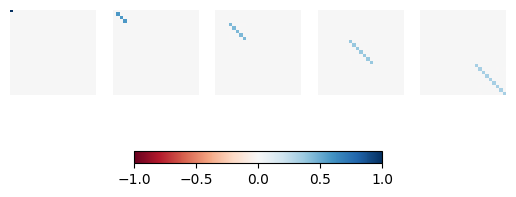

In [5]:
# Visualize: project each scalar path back to the (Lmax+1)^2 x (Lmax+1)^2 SH-indexed matrix
scalar_cob = np.einsum('nsi,ij->nsj', cob[0], new_basis)
vis.plot_matrices(
    scalar_cob.reshape(-1, (Lmax + 1) ** 2, (Lmax + 1) ** 2),
    cmap='RdBu',
);

Each panel shows one of the 5 scalar paths, drawn as a $25 \times 25$ matrix on the SH-indexed grid. The block-diagonal structure makes the per-frequency norm structure visible: each scalar path is a contraction within a single $L$-block.

## Bispectrum

The **bispectrum** is the rank-3 analog: a *fully symmetric* scalar contraction

$$B_{L_1 L_2 L_3} = \sum_{m_1, m_2, m_3} C^{L_3 m_3}_{L_1 m_1, L_2 m_2} \, \hat f_{L_1}^{m_1} \, \hat f_{L_2}^{m_2} \, \hat f_{L_3}^{m_3}$$

with the index-permutation constraint $ijk = jik = ikj$. The number of scalar paths is the number of valid bispectrum components — driven by the **triangle inequality** $|L_1 - L_2| \leq L_3 \leq L_1 + L_2$ (CG selection rule) and the parity constraint $(-1)^{L_1 + L_2 + L_3} = +1$ for scalars (or $-1$ for pseudoscalars).

**Cost warning.** The full triple tensor product has dimension $d^3$; for $d = 16$ ($L_{\max} = 3$ on the $0e \oplus 1o \oplus 2e \oplus 3o$ direct sum) that's already $4096^2 = 16.8$M entries. We cap at $L_{\max} = 3$. Higher $L_{\max}$ blows up rapidly — that's where e3nn-jax wins.

In [6]:
# Cap at Lmax = 3 for tractability of the triple tensor product
sh_labels_3 = ['0e', '1o', '2e', '3o']
sh_rep_idx = [o3_ir_labels.index(label) for label in sh_labels_3]
sh_rep = rep.direct_sum_multiple([o3_irreps[i] for i in sh_rep_idx])
_, d, _ = sh_rep.shape
print(f'Dimension of SH up to Lmax = 3: d = {d}')

# Triple tensor product (this takes a minute)
bi_spectra_full = rep.tensor_product(rep.tensor_product(sh_rep, sh_rep), sh_rep)
print('Triple tensor product dim:', bi_spectra_full.shape)

Dimension of SH up to Lmax = 3: d = 16
Triple tensor product dim: (10, 4096, 4096)


**The next cell takes a few minutes.** The fully-symmetric projector for rank-3 has 6 elements (the symmetric group $S_3$); building the symmetric subspace and finding equivariant maps to $(0e)$ and $(0o)$ involves dense linear algebra at dimension $d^3 = 4096$. This is the price of doing it from first principles.

In [7]:
# Symmetric subspace for fully-symmetric rank 3: ijk = jik = ikj
perm_rep, sign_rep = grids.formula_to_perm_and_sign_group('ijk=jik=ikj')
new_basis, new_proj = grids.perm_and_sign_to_tensor_basis_and_proj(
    perm_rep, sign_rep, [d, d, d]
)

tp_sub = new_basis @ bi_spectra_full @ new_basis.T

scalars_and_pseudoscalar = [o3_ir_labels.index(label) for label in ['0e', '0o']]
cob = [
    linalg.infer_change_of_basis(ir, tp_sub)
    for ir in [o3_irreps[i] for i in scalars_and_pseudoscalar]
]

print('Number of scalar (0e) paths:    ', cob[0].shape[0])
print('Number of pseudoscalar (0o) paths:', cob[1].shape[0])

Number of scalar (0e) paths:     8
Number of pseudoscalar (0o) paths: 0


**Interpretation.** Each scalar path corresponds to one bispectrum entry $B_{L_1 L_2 L_3}$. The path exists when:

1. The triangle inequality $|L_1 - L_2| \leq L_3 \leq L_1 + L_2$ is satisfied (CG selection rule),
2. The fully-symmetric tensor-product subspace at $(L_1, L_2, L_3)$ has a nonzero projection onto $(0e)$ — equivalently, $L_1 + L_2 + L_3$ is **even** (parity of the product = $+1$, hence scalar rather than pseudoscalar).

The pseudoscalar $(0o)$ paths arise when $L_1 + L_2 + L_3$ is **odd** — also valid bispectrum entries, just with parity $-1$ under inversion.

Enumerating valid $(L_1, L_2, L_3)$ triples with $L_i \leq 3$, even sum, and the triangle inequality — modulo the index-symmetry $ijk = jik = ikj$ — should match the scalar path count above.

/var/folders/ft/yzqgn6yj3v34d4jzmhcxx5c00000gn/T/ipykernel_15816/931640699.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


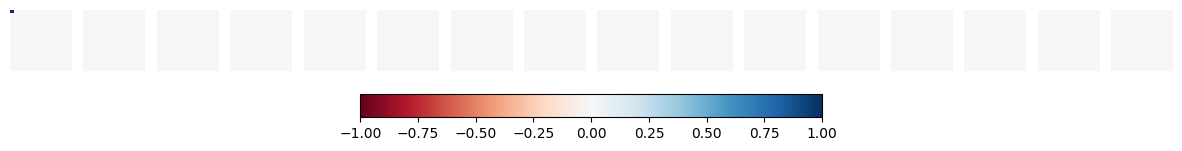

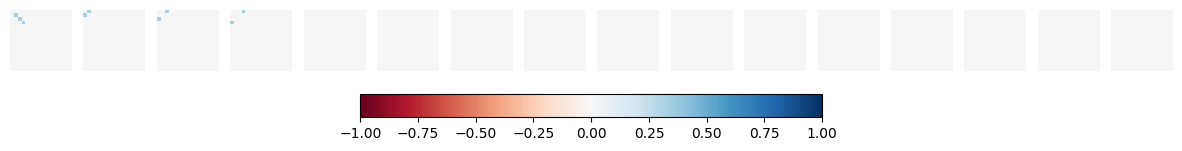

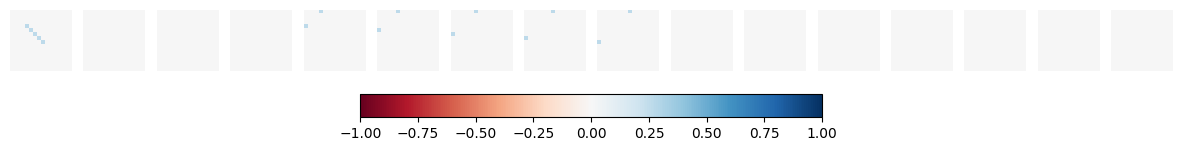

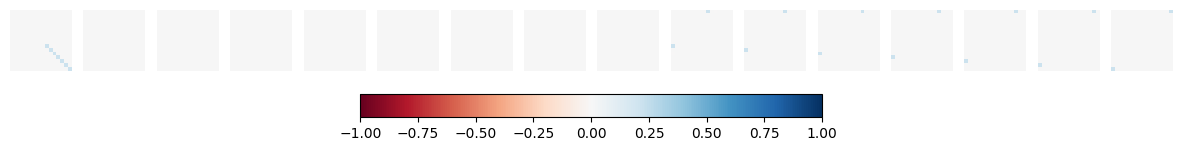

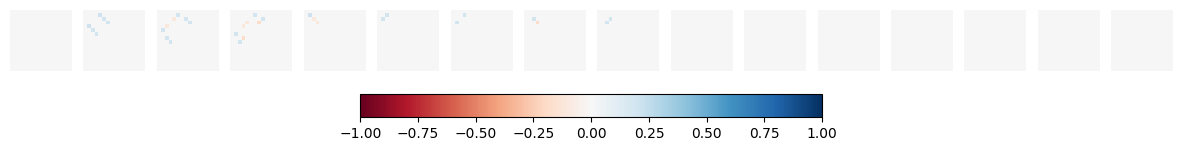

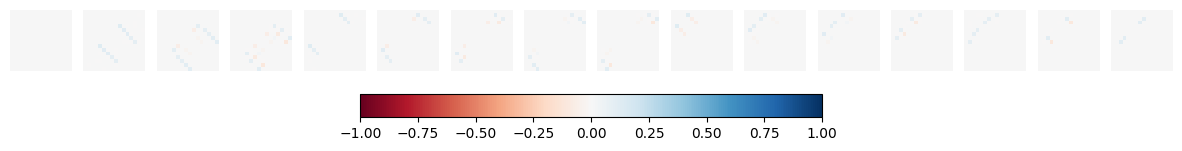

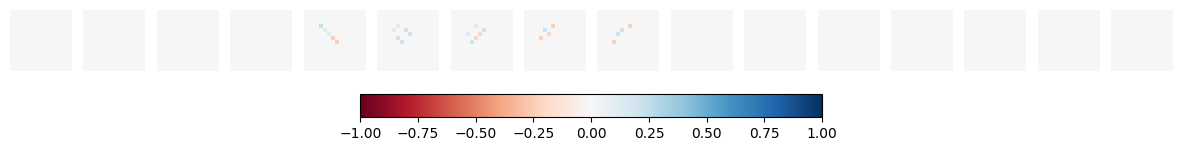

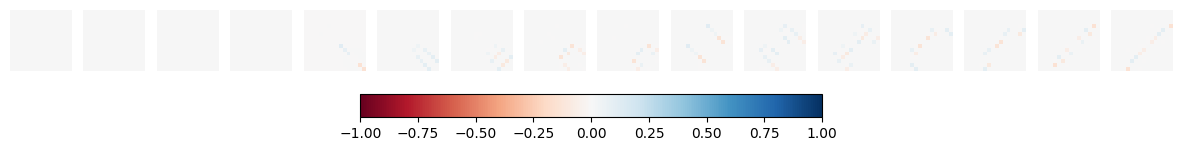

In [8]:
# Visualize the scalar paths back-projected to the d^3 SH-indexed cube
scalar_cob = np.einsum('nsi,ij->nsj', cob[0], new_basis)
for i in range(len(scalar_cob)):
    fig = vis.plot_matrices(
        scalar_cob[i].reshape((3 + 1) ** 2, (3 + 1) ** 2, (3 + 1) ** 2),
        cmap='RdBu',
        figsize=(15, 2),
    )
    fig.show()

Each row visualizes one bispectrum scalar path as a stack of 16 $16 \times 16$ slices through the $d^3 = 4096$-dimensional triple-tensor space. The block-sparse pattern reveals which $(L_1, L_2, L_3)$ combinations contribute to each invariant.

## Connection to e3nn

In `e3nn` (and `e3nn-jax`), the same calculations are done with **precomputed Clebsch–Gordan coefficients** rather than constructing the tensor-product representation explicitly:

```python
import e3nn
import e3nn.o3

# SH irreps up to Lmax
irreps = e3nn.o3.Irreps.spherical_harmonics(Lmax)

# Power spectrum: symmetric ij = ji rank-2 invariant, project to 0e + 0o
power_spectrum_op = e3nn.o3.ReducedTensorProducts(
    'ij=ji', i=irreps, filter_ir_out=['0e']
)

# Bispectrum: fully-symmetric ijk = jik = ikj rank-3, filter to 0e + 0o
bispectrum_op = e3nn.o3.ReducedTensorProducts(
    'ijk=jik=ikj', i=irreps, filter_ir_out=['0e', '0o']
)
```

`ReducedTensorProducts` does the same projection-to-symmetric-subspace + filter-to-target-irrep machinery that we just did by hand — but with hand-tuned CG contractions and JIT compilation, so it scales to $L_{\max} = 6$+ for bispectra without breaking a sweat. The conceptual content is identical to what we did above; the difference is purely computational. For production atomistic ML (SOAP, ACE, etc.), use e3nn or e3nn-jax. For learning what the descriptor actually *is*, the from-scratch course-code construction is more transparent.